# 3. 线性神经网络
## 3.1 线性回归

> 参考：《动手学深度学习》 [3.1 线性回归](https://zh-v2.d2l.ai/chapter_linear-networks/linear-regression.html)

**回归**（regression）是能为一个或多个自变量与因变量之间关系建模的一类方法。在自然科学和社会科学领域，回归经常用来表示输入和输出之间的关系。

在机器学习领域中，大多数任务都与*预测*有关。当我们想预测一个**数值**时，就会涉及回归问题。常见的例子包括：

* 预测价格（房屋、股票等）
* 预测住院时间
* 预测体育赛事胜负概率（对数回归）

**本文以房价预测为例**：我们希望根据房屋的**面积**（平方英尺）和**房龄**（年）来估算房屋的**价格**（美元）。为了实际拟合这个模型，我们需要收集真实数据集——一栋房子的实际售价、面积和房龄。于是机器学习的术语如下：

| 术语 | 英文 | 含义 |
|------|------|------|
| 训练数据集 / 训练集 | training data set / training set | 用来拟合模型参数的真实数据 |
| 样本 / 数据点 | sample / data point | 数据集中的每一行数据 |
| 标签 / 目标 | label / target | 要预测的内容（这里是价格） |
| 特征 / 协变量 | feature / covariate | 预测所依据的自变量（这里是面积和房龄） |

一个线性回归模型的完整要素包括：**模型**（线性模型）、**损失函数**、**优化算法**（随机梯度下降）。下面逐一展开。

### 1. 线性模型

线性假设是指：目标（价格 $\mathrm{price}$）可以表示为特征（面积 $\mathrm{area}$ 和房龄 $\mathrm{age}$）的**加权和**：

$$\mathrm{price} = w_{\mathrm{area}} \cdot \mathrm{area} + w_{\mathrm{age}} \cdot \mathrm{age} + b$$

* $w_{\mathrm{area}}$ 和 $w_{\mathrm{age}}$ 称为**权重**（weight）。权重越大，说明对应特征对预测结果的影响越大。
* $b$ 称为**偏置**（bias）、偏移量（offset）或**截距**（intercept）。当所有特征都取 0 时，偏置就是预测值，表示价格的"基础水平"。

**一般形式**：给定数据集 $\{\mathbf{x}^{(1)}, \dots, \mathbf{x}^{(n)}\}$（$n$ 个样本，每个样本有 $d$ 个特征），线性模型的预测为：

$$\hat{y} = w_1 x_1 + \cdots + w_d x_d + b$$

**向量形式**（点积）：

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b, \qquad \mathbf{w}^\top \mathbf{x} = \sum_{i=1}^{d} w_i x_i$$

其中 $\mathbf{x} \in \mathbb{R}^d$ 是特征向量，$\mathbf{w} \in \mathbb{R}^d$ 是权重向量。

**矩阵形式**：对整个数据集，把 $n$ 个样本按行堆叠成设计矩阵 $\mathbf{X} \in \mathbb{R}^{n \times d}$，预测向量 $\hat{\mathbf{y}} \in \mathbb{R}^n$ 为：

$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b$$

> * 通过矩阵-向量乘法，一行样本对应一个预测值，一次矩阵运算即可完成全部 $n$ 个样本的预测（矢量化，见后文）。
> * 偏置 $b$ 会借助**广播机制**加到每一个样本的预测上。
>
> 给定特征 $\mathbf{X}$，目标是寻找权重向量 $\mathbf{w}$ 和偏置 $b$，使得 $\hat{\mathbf{y}}$ 尽可能接近真实标签 $\mathbf{y}$。

**严格来说**，$\mathbf{X}\mathbf{w} + b$ 这种加入标量参数的做法属于**仿射变换**（affine transformation）——带有偏置项的线性变换。深度网络之所以"深"，就是因为在仿射变换之后叠加了多层非线性变换。

### 2. 损失函数（Loss Function）

在开始思考如何**拟合**（fit）模型之前，我们需要决定如何衡量模型的拟合质量。

**损失函数**（loss function）能够量化目标的**实际值与预测值之间的差距**。通常我们选择非负数作为损失，且数值越小表示损失越小，完美预测时损失为 0。

回归问题最常用的损失函数是**平方误差函数**（squared error function，也称 **L2 损失**）。当样本 $i$ 的预测值为 $\hat{y}^{(i)}$、真实标签为 $y^{(i)}$ 时，平方误差定义为：

$$l^{(i)}(\mathbf{w}, b) = \frac{1}{2}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

> **为什么有系数 $\frac{1}{2}$？** 它对优化结果没有任何影响（只是缩放），但求导后刚好把平方的 2 消掉，使梯度形式更简洁：
>
> $$\frac{\partial}{\partial \hat{y}^{(i)}}\ \frac{1}{2}\left(\hat{y}^{(i)} - y^{(i)}\right)^2 = \hat{y}^{(i)} - y^{(i)}$$

下图中，蓝色直线就是用线性模型拟合数据的结果，样本点到直线的**竖直距离**就是各样本的平方误差（残差）——直线越贴近数据点，损失越小。

![用线性模型拟合数据](src/fit-linreg.svg)

**训练损失（经验风险）**：由于平方误差对较大的差异惩罚更重，训练时我们希望寻找一组参数 $(\mathbf{w}^*, b^*)$，**最小化所有训练样本上的平均损失**：

$$L(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^{n} l^{(i)}(\mathbf{w}, b) = \frac{1}{2n}\sum_{i=1}^{n} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2$$

**优化目标**：

$$\mathbf{w}^*, b^* = \operatorname*{argmin}_{\mathbf{w}, b}\ L(\mathbf{w}, b)$$

**MSE 与 L1 损失的对比**：

| | 均方误差 MSE（L2） | 绝对误差 MAE（L1） |
|---|---|---|
| 定义 | $\frac{1}{2}(\hat{y} - y)^2$ | $\|\hat{y} - y\|$ |
| 梯度 | $\hat{y} - y$（误差越大梯度越大） | $\pm 1$（恒定） |
| 对异常值 | 敏感（平方放大 outlier 的影响） | 稳健 |
| 最优点附近 | 梯度逐渐减小，收敛平稳 | 梯度不减小，最小值处不可导 |

回归中 MSE 是默认选择，而训练数据中的异常值（如测量错误）会对 MSE 影响很大——此时 L1 损失更稳健。

#### 2.1 解析解（Analytical Solution）

线性回归的损失 $L(\mathbf{w}, b)$ 是**凸函数**，属于"简单的优化问题"，最优解可以用公式直接表达出来，这类解叫**解析解**。

**推导**：为方便矩阵运算，把偏置 $b$ 吸收进权重向量——给每个样本增加一个恒为 $1$ 的特征列，得到增广设计矩阵 $\mathbf{X} \in \mathbb{R}^{n \times (d+1)}$，增广权重向量 $\mathbf{w}$（含 $b$）。此时损失可写为矩阵形式：

$$L(\mathbf{w}) = \frac{1}{2n}\left\|\mathbf{X}\mathbf{w} - \mathbf{y}\right\|^2$$

**第一步：求梯度**（利用矩阵微积分 $\nabla_{\mathbf{w}}\|\mathbf{X}\mathbf{w}-\mathbf{y}\|^2 = 2\mathbf{X}^\top(\mathbf{X}\mathbf{w}-\mathbf{y})$）：

$$\frac{\partial L}{\partial \mathbf{w}} = \frac{1}{n}\mathbf{X}^\top(\mathbf{X}\mathbf{w} - \mathbf{y})$$

**第二步：令梯度为零**，得到**正规方程**（normal equations）：

$$\mathbf{X}^\top\mathbf{X}\mathbf{w} = \mathbf{X}^\top\mathbf{y}$$

**第三步：当 $\mathbf{X}^\top\mathbf{X}$ 可逆时**，最优解为：

$$\boxed{\ \mathbf{w}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}\ }$$

**局限性**：

1. 并不是所有问题都有解析解。解析解只对线性回归这类简单问题有效；深度神经网络根本没有解析解。
2. 即使存在解析解，当特征维度 $d$ 很大时，矩阵求逆的代价约为 $\mathcal{O}(d^3)$，可能比迭代优化更昂贵。

因此实践中更常用的方法是**数值优化的迭代方法**——梯度下降。

### 3. 随机梯度下降（Stochastic Gradient Descent, SGD）

#### 3.1 梯度下降的直觉

损失 $L(\mathbf{w}, b)$ 关于参数的梯度 $\nabla_{(\mathbf{w},b)} L$ 指向损失**上升最快**的方向，那么它的**反方向**就是下降最快的方向。于是从随机初始化出发，沿负梯度方向一小步一小步地走：

$$\mathbf{w} \leftarrow \mathbf{w} - \eta\, \nabla_{\mathbf{w}} L(\mathbf{w}, b), \qquad b \leftarrow b - \eta\, \frac{\partial L}{\partial b}$$

其中 $\eta > 0$ 是**学习率**（learning rate），控制每一步走多远。

**问题**：每次更新都要对**全部 $n$ 个训练样本**求和来计算梯度。当数据集非常大时，单次更新的代价就非常高，甚至整个数据集都装不进内存。

#### 3.2 随机梯度下降（SGD）

**SGD 的核心思想：每次只用一个（或一小批）随机抽取的样本来估计梯度。**

最朴素的（单样本）随机梯度下降：

$$\mathbf{w} \leftarrow \mathbf{w} - \eta\, \nabla_{\mathbf{w}}\, l^{(i)}(\mathbf{w}, b), \qquad i \sim \text{Uniform}\{1,\dots,n\}$$

**为什么这是合理的？——无偏估计**。随机抽取的样本 $i$ 的梯度是全体样本平均梯度的**无偏估计**（unbiased estimate）：

$$\mathbb{E}_{i}\left[\nabla_{\mathbf{w}}\, l^{(i)}(\mathbf{w}, b)\right] = \frac{1}{n}\sum_{i=1}^{n} \nabla_{\mathbf{w}}\, l^{(i)}(\mathbf{w}, b) = \nabla_{\mathbf{w}}\, L(\mathbf{w}, b)$$

即：虽然每次只看一个样本，但**平均而言**它指的方向和完整梯度一样，只是方差较大、路径"抖动"。

#### 3.3 小批量随机梯度下降（minibatch SGD）—— 实践标准

单样本更新太"抖"，且逐样本计算难以充分利用 GPU 的并行能力。实践中的标准做法是折中：每次迭代抽取**一小批量**（minibatch）样本 $\mathcal{B}$，用批量内样本的平均梯度更新参数。

**算法流程**：

1. 初始化模型参数 $(\mathbf{w}_0, b_0)$（通常随机初始化）；
2. 重复以下步骤直到收敛：
   * 从训练集中随机抽取一个小批量 $\mathcal{B}_t = \{(\mathbf{x}_1, y_1), \dots, (\mathbf{x}_B, y_B)\}$，其中 $B = |\mathcal{B}|$ 称为**批量大小**（batch size）；
   * 计算批量内损失的平均梯度；
   * 沿负梯度方向更新参数。

**参数更新公式**（$\partial$ 表示对 $(\mathbf{w}, b)$ 求梯度）：

$$\boxed{\ (\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}_t} \partial_{(\mathbf{w}, b)}\, l^{(i)}(\mathbf{w}, b)\ }$$

**无偏性**：小批量梯度同样是无偏估计，且批量越大方差越小（方差以 $1/B$ 的速率减小）：

$$\mathbb{E}_{\mathcal{B}}\left[\frac{1}{|\mathcal{B}|}\sum_{i \in \mathcal{B}} \nabla\, l^{(i)}(\mathbf{w}, b)\right] = \nabla\, L(\mathbf{w}, b)$$

> **关于采样方式**：理论上"有放回"抽样与"无放回"抽样都可行；有放回抽样时上式的无偏性严格成立，便于理论分析。实践中通常先随机打乱全部样本、再按顺序切分成小批量（相当于无放回），每个 epoch 重新打乱一次。

#### 3.4 两个关键超参数

| 超参数 | 含义 | 太小 | 太大 |
|--------|------|------|------|
| 学习率 $\eta$ | 每步沿负梯度走多远 | 收敛缓慢，浪费算力 | 跨过最优点，震荡甚至发散 |
| 批量大小 $B$ | 每次更新使用的样本数 | 硬件并行利用率低、梯度噪声大 | 显存占用高、单次更新昂贵、可能被个别糟糕方向带偏 |

**实践要点**：

* 批量大小的选择常受**GPU 显存**限制；
* 批量内计算在 GPU 上**高度并行**：把批量从 $B$ 扩大到 $2B$，几乎不会增加单次更新的耗时——因此**在算力允许时选大一点的批量**，并相应**放大学习率**（批量越大、梯度方差越小，可以容忍更大的步长）；
* **收敛性质**：对于**凸**损失函数，若梯度范数有界且学习率满足一定条件（如 $\eta_t \propto 1/\sqrt{t}$），SGD 在期望意义下以 $\mathcal{O}(1/\sqrt{t})$ 的速率收敛到全局最优；对深度网络这样的非凸问题，SGD 同样是最主流的优化器；
* 实践中学习率常按"epoch"分段衰减，而不是严格按 $1/\sqrt{t}$ 衰减。

#### 3.5 用模型进行预测（推断）

训练完成后，可以用学到的参数 $\hat{\mathbf{w}}, \hat{b}$ 对**新样本**做预测（也称**推断**，inference）。例如给定一套新房的面积 $\mathbf{x}$，预测价格为：

$$\hat{y} = \hat{\mathbf{w}}^\top \mathbf{x} + \hat{b}$$

由于这里是我们**手工挑选**的特征（面积、房龄），这个练习其实属于标准统计学的范畴，还算不上真正的"学习"。后面章节会看到，深度学习可以自动学习特征表示。

#### 3.6 动手验证：小批量 SGD 从零实现

用带噪声的线性模型生成合成数据 $y = 2x_1 - 3.4x_2 + 4.2 + \epsilon$，再用上一节的小批量 SGD 把参数"学"回来。

In [63]:
import random
import torch

def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声。"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)  # 加上均值为0、标准差0.01的高斯噪声
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

print('X 的形状:', features.shape, '  y 的形状:', labels.shape)
print('第一个样本:', features[0], '  对应标签:', labels[0])

X 的形状: torch.Size([1000, 2])   y 的形状: torch.Size([1000, 1])
第一个样本: tensor([ 2.0709, -0.8109])   对应标签: tensor([11.0884])


In [64]:
def data_iter(batch_size, X, y):
    """小批量数据迭代器：每个 epoch 随机打乱样本，按批量大小切分。"""
    num_examples = len(X)
    indices = list(range(num_examples))
    random.shuffle(indices)  # 随机打乱，保证批量内样本是随机抽取的
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i : min(i + batch_size, num_examples)])
        print("batch_indices:", batch_indices)
        yield X[batch_indices], y[batch_indices]


batch_size = 10
for X_b, y_b in data_iter(batch_size, features, labels):
    print("第一个批量的特征:\n", X_b[:3])
    print("第一个批量的标签:\n", y_b[:3])
    break

batch_indices: tensor([891, 957,  11, 529, 691, 426, 615, 642, 237, 256])
第一个批量的特征:
 tensor([[ 1.9451, -1.1039],
        [-0.6218, -0.6421],
        [-1.4977,  0.0358]])
第一个批量的标签:
 tensor([[11.8325],
        [ 5.1438],
        [ 1.0669]])


In [71]:
# 初始化参数（从正态分布中随机取 w，b 置 0），并开启梯度追踪
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def linreg(X, w, b):
    """线性回归模型：y = Xw + b。"""
    return torch.matmul(X, w) + b

def squared_loss(y_hat, y):
    """平方损失（逐样本，未求均值）。"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

lr = 0.03        # 学习率 η
num_epochs = 3   # 完整遍历数据集的轮数
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X_b, y_b in data_iter(batch_size, features, labels):
        l = loss(net(X_b, w, b), y_b)   # 小批量损失，形状 (batch_size, 1)
        print(f'l:{l}')
        l.sum().backward()              # 对 (w, b) 反向传播求梯度
        with torch.no_grad():           # 参数更新不需要参与梯度计算
            # 对应公式：(w, b) <- (w, b) - η/|B| * Σ ∂l
            w -= lr * w.grad / batch_size
            b -= lr * b.grad / batch_size
            w.grad.zero_()              # 梯度清零，为下一次迭代做准备
            b.grad.zero_()
    train_l = loss(net(features, w, b), labels)
    print(f'epoch {epoch + 1}, 平均损失 {train_l.mean():f}')

print(f'w 的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b 的估计误差: {true_b - b}')

batch_indices: tensor([234,  68, 553, 850, 115, 845, 132, 852, 743, 602])
l:tensor([[ 3.0471],
        [11.9249],
        [ 7.5963],
        [ 3.7813],
        [ 5.4034],
        [30.5951],
        [12.8185],
        [ 0.7349],
        [15.9040],
        [76.5101]], grad_fn=<DivBackward0>)
batch_indices: tensor([939, 479, 290, 884, 800, 220, 821, 842, 551, 664])
l:tensor([[ 0.0741],
        [ 4.1578],
        [32.2800],
        [25.9676],
        [ 9.3928],
        [ 2.5731],
        [ 2.5689],
        [25.3312],
        [42.3590],
        [16.3488]], grad_fn=<DivBackward0>)
batch_indices: tensor([706, 126, 459, 381, 205, 690, 428, 545, 251, 552])
l:tensor([[ 0.1084],
        [ 5.0797],
        [23.1065],
        [ 0.0269],
        [ 0.1407],
        [ 1.2780],
        [10.4161],
        [ 0.3420],
        [ 3.9613],
        [ 2.0154]], grad_fn=<DivBackward0>)
batch_indices: tensor([324, 843, 461, 890, 368, 868, 491,  73,  11, 288])
l:tensor([[5.9234e+00],
        [1.1820e+00],
       

### 4. 矢量化加速

训练模型需要时间，优化算法的效率至关重要。深度学习框架提供的高度优化的**矢量化**（vectorization）运算，比手写 `for` 循环快几个数量级。原因：矢量化运算直接调用底层 C++/CUDA 实现的矩阵运算，避免了 Python 解释器的逐元素开销。

下面用 `Timer` 类实测：对两个长度为 10000 的向量做加法，逐元素 `for` 循环 vs 矢量化 `a + b`。

In [72]:
import math
import time
import numpy as np

class Timer:
    """记录多次运行时间。"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器。"""
        self.tik = time.perf_counter()

    def stop(self):
        """停止计时器并把时间记录到列表中。"""
        self.times.append(time.perf_counter() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间。"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和。"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间。"""
        return np.array(self.times).cumsum().tolist()


n = 10000
a = torch.ones(n)
b = torch.ones(n)

# 方式一：for 循环逐元素相加
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
print(f'for 循环: {timer.stop():.5f} 秒')

# 方式二：矢量化加法
timer.start()
d = a + b
print(f'矢量化: {timer.stop():.5f} 秒')
print(f'加速比约 {timer.times[0] / timer.times[1]:.0f} 倍')

for 循环: 0.05385 秒
矢量化: 0.00029 秒
加速比约 188 倍


### 5. 正态分布与平方损失 —— 为什么用平方损失？

前面我们"理所当然"地使用了平方损失。它为什么是回归问题的合适损失？本节通过**极大似然估计**（Maximum Likelihood Estimation, MLE）给出严格的理论依据——这也是本节最重要的推理。

#### 5.1 正态分布

**正态分布**（normal distribution，也叫**高斯分布**，Gaussian distribution）是统计学中最常见的分布，其概率密度函数为：

$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{1}{2\sigma^2}(x - \mu)^2\right)$$

* 均值 $\mu$：控制分布的**中心位置**（平移曲线）；
* 方差 $\sigma^2$：控制分布的**离散程度**（$\sigma$ 越大曲线越"矮胖"，越小越"高瘦"）。

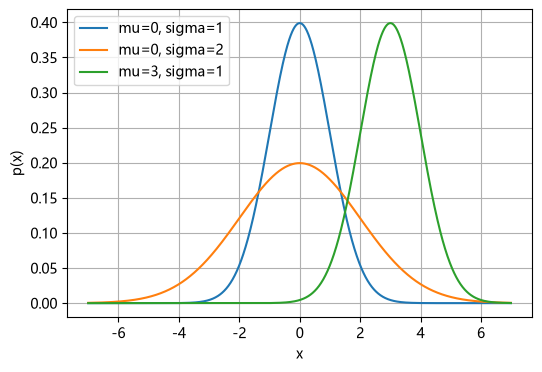

In [73]:
import matplotlib.pyplot as plt

def normal(x, mu, sigma):
    """正态分布的概率密度函数。"""
    p = 1 / math.sqrt(2 * math.pi * sigma ** 2)
    return p * np.exp(-0.5 / sigma ** 2 * (x - mu) ** 2)

x = np.arange(-7, 7, 0.01)

# 改变均值产生沿 x 轴的平移，改变方差则分散或者集中概率密度
params = [(0, 1), (0, 2), (3, 1)]
plt.figure(figsize=(6, 4))
for mu, sigma in params:
    plt.plot(x, normal(x, mu, sigma), label=f'mu={mu}, sigma={sigma}')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.grid(True)
plt.show()

#### 5.2 噪声假设

线性回归假设观测值由真实函数加上噪声得到：

$$y = \mathbf{w}^\top\mathbf{x} + b + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

其中 $\epsilon$ 是服从正态分布的噪声。于是，**给定特征 $\mathbf{x}$，标签 $y$ 的条件分布也是正态分布**，中心在模型的预测值处：

$$P(y \mid \mathbf{x}) = \mathcal{N}\left(y \mid \mathbf{w}^\top\mathbf{x} + b,\ \sigma^2\right) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{1}{2\sigma^2}\left(y - \mathbf{w}^\top\mathbf{x} - b\right)^2\right)$$

#### 5.3 极大似然估计的完整推理（重点）

**极大似然估计的思想**：既然数据已经被观测到了，那就挑选一组参数，使"**这批数据被观测到的概率**"（即**似然**）最大。

**第一步：写出单个样本的似然。**

似然 $P(y^{(i)} \mid \mathbf{x}^{(i)})$ 表示"在参数 $(\mathbf{w}, b, \sigma)$ 给定时，观测到样本 $(\mathbf{x}^{(i)}, y^{(i)})$ 的可能性"，它就是上面的条件密度。

**第二步：写出全体样本的联合似然（连乘）。**

假设样本 $\{(\mathbf{x}^{(1)}, y^{(1)}), \dots, (\mathbf{x}^{(n)}, y^{(n)})\}$ 是**独立同分布**（i.i.d.）的，则联合似然是每个样本似然的**乘积**：

$$P(\mathbf{y} \mid \mathbf{X}) = \prod_{i=1}^{n} P\left(y^{(i)} \mid \mathbf{x}^{(i)}\right) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{1}{2\sigma^2}\left(y^{(i)} - \mathbf{w}^\top\mathbf{x}^{(i)} - b\right)^2\right)$$

极大似然估计即求解：

$$\operatorname*{argmax}_{\mathbf{w}, b, \sigma}\ P(\mathbf{y} \mid \mathbf{X})$$

**第三步：取对数（连乘 → 连加）。**

连乘的乘积数值极小（容易数值下溢）且难以求导。由于 $\log$ 是**严格递增函数**，最大化似然与最大化**对数似然**完全等价：

$$\log P(\mathbf{y} \mid \mathbf{X}) = \sum_{i=1}^{n} \log P\left(y^{(i)} \mid \mathbf{x}^{(i)}\right) = \sum_{i=1}^{n}\left[-\frac{1}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\left(y^{(i)} - \mathbf{w}^\top\mathbf{x}^{(i)} - b\right)^2\right]$$

**第四步：最小化负对数似然。**

最大化对数似然 $\iff$ 最小化**负对数似然**（negative log-likelihood）：

$$-\log P(\mathbf{y} \mid \mathbf{X}) = \sum_{i=1}^{n}\left[\frac{1}{2}\log(2\pi\sigma^2) + \frac{1}{2\sigma^2}\left(y^{(i)} - \mathbf{w}^\top\mathbf{x}^{(i)} - b\right)^2\right]$$

**第五步：识别出平方损失（关键观察）。**

现在的目标是关于 $(\mathbf{w}, b)$ 最小化上式。注意：

* 常数项 $\frac{1}{2}\log(2\pi\sigma^2)$ **与 $(\mathbf{w}, b)$ 无关**，不影响最优解；
* 系数 $\frac{1}{2\sigma^2}$ 只是一个**正的常数缩放**，同样不改变关于 $(\mathbf{w}, b)$ 的 $\operatorname*{argmin}$。

于是问题等价于：

$$\operatorname*{argmin}_{\mathbf{w}, b}\ \sum_{i=1}^{n}\left(y^{(i)} - \mathbf{w}^\top\mathbf{x}^{(i)} - b\right)^2$$

**这正是最小化平方误差（均方损失）的目标！**

#### 5.4 结论

> 在**高斯噪声假设**下，**最小化均方误差 $\iff$ 对线性模型做极大似然估计**。

平方损失并不是随意选择的，而是由"噪声服从正态分布"这一假设，经似然推理**自然导出**的。

> **补充**：若把 $\sigma$ 也当作待估参数，对它求导可得 $\hat{\sigma}^2 = \frac{1}{n}\sum_i\left(\hat{y}^{(i)} - y^{(i)}\right)^2$，即残差方差——这给出了模型预测的"不确定度"。

#### 5.5 对偶视角：如果噪声是 Laplace 分布？—— L1 损失的由来

同样的推理框架换个噪声假设，会导出不同的损失。假设噪声服从**拉普拉斯分布**（Laplace distribution）：

$$p(\epsilon) = \frac{1}{2\lambda}\exp\left(-\frac{|\epsilon|}{\lambda}\right)$$

写出似然 → 取对数 → 最小化负对数似然，会得到最小化**绝对误差**：

$$\operatorname*{argmin}_{\mathbf{w}, b}\ \sum_{i=1}^{n}\left|y^{(i)} - \mathbf{w}^\top\mathbf{x}^{(i)} - b\right|$$

这就是 **L1 损失**（平均绝对误差 MAE）的理论来源。

| 噪声假设 | 由负对数似然导出的损失 |
|----------|------------------------|
| 正态（高斯）$\mathcal{N}(0, \sigma^2)$ | 平方损失（L2 / MSE） |
| 拉普拉斯 $\mathrm{Laplace}(0, \lambda)$ | 绝对值损失（L1 / MAE） |

**损失函数的选择 = 对噪声分布的假设**，这是连接"统计模型"与"优化目标"的核心桥梁。

### 6. 从线性回归到深度网络

虽然神经网络能表达比线性模型丰富得多的函数，但我们仍可以用描述神经网络的方式描述线性模型——把它看作一个"最简单"的神经网络，从而建立从线性模型到深度网络的桥梁。

#### 6.1 神经网络图示

把线性回归模型画成神经网络：

![线性回归是一个单层神经网络](src/singleneuron.svg)

* **输入**：样本特征 $x_1, \dots, x_d$（图中 $d = 3$），输入层的神经元数即输入维度；
* **输出**：$\mathbf{w}^\top\mathbf{x} + b$ 的计算结果 $o_1$，输出层的神经元数即输出维度；
* 图中只显示**连接模式**（每个输入与每个输出相连），省略了权重和偏置的具体取值；
* 由于输入层不涉及任何计算，按照惯例（输入层不计层数），线性回归是一个**单层神经网络**；
* 输出数为 1 时是单变量回归；若要同时预测多个值（如房价、面积、单价），则是**多变量回归**。

#### 6.2 全连接层

对于线性回归，**每个输入都与每个输出相连**（本例只有一个输出）：

$$o_1 = w_{11}x_1 + w_{12}x_2 + w_{13}x_3 + b_1$$

这种变换称为**全连接层**（fully-connected layer）或**稠密层**（dense layer）。后续章节会大量使用它。

> 也存在无法用这种"标准神经网络层"描述的模型（如决策树），它们同样有输入与输出，只是计算方式不同。

#### 6.3 生物学上的合理性（可选阅读）

线性回归最早由高斯于 1795 年提出（最小二乘法）。而"人工神经元"的思想，来自对**生物神经元**的粗糙类比：

![生物神经元](src/neuron.svg)

* **树突**（dendrite）：接收来自其他神经元的电信号 —— 对应输入 $x_i$；
* **轴突**（axon）：向其他神经元输出信号 —— 对应输出 $o$；
* **突触**（synapse）：神经元之间的连接，信号强度可变 —— 对应权重 $w_i$；
* 当输入信号的加权强度超过某个阈值时，神经元被激活 —— 类似偏置 $b$ 与激活函数的思想。

两者思想的共同点在于"**信息的加权聚合**"，但真实生物神经元的复杂程度远超这一简单模型。

# 线性回归的简洁实现

## 生成数据集

In [74]:
import numpy as np
import torch
from torch.utils import data

In [75]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features shape:', features.shape)


features shape: torch.Size([1000, 2])


## 读取数据集


In [76]:
def load_array(data_arrays,batch_size,is_train=True):
    """构造一个Pytorch数据迭代器"""
    dataset=data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

In [77]:
batch_size = 10
data_iter = load_array((features, labels), batch_size)
next(iter(data_iter))

[tensor([[ 0.5307, -0.5843],
         [-1.1204, -0.2059],
         [ 0.4579,  1.4731],
         [ 1.6695,  2.1238],
         [-0.8354,  0.2397],
         [ 0.7999, -1.3805],
         [-0.0954,  1.6460],
         [-0.3967,  0.1929],
         [ 0.7101,  0.3981],
         [ 0.0025,  0.0333]]),
 tensor([[ 7.2416],
         [ 2.6638],
         [ 0.1069],
         [ 0.3122],
         [ 1.7076],
         [10.4883],
         [-1.5802],
         [ 2.7611],
         [ 4.2720],
         [ 4.0917]])]

## 定义模型

In [78]:
from torch import nn

net=nn.Sequential(nn.Linear(2,1))

## 定义损失函数

In [79]:
loss=nn.MSELoss()

## 定义优化算法

In [80]:
trainer=torch.optim.SGD(net.parameters(),lr=0.03)
print(net.parameters())

<generator object Module.parameters at 0x000001B54BC96420>


## 训练

In [81]:
num_epochs=3

for eopch in range(num_epochs):
    for X,y in data_iter:
        l=loss(net(X),y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    print(f"epoch {eopch}, loss {l.item():.4f}")

epoch 0, loss 0.0002
epoch 1, loss 0.0001
epoch 2, loss 0.0001


In [51]:
w=net[0].weight.data
print('w的估计误差:',true_w-w.reshape(true_w.shape))
b=net[0].bias.data
print('b的估计误差:',true_b-b)


w的估计误差: tensor([-0.0003, -0.0006])
b的估计误差: tensor([0.0007])


## 3.4 softmax回归

> 参考：《动手学深度学习》 [3.4 softmax回归](https://zh-v2.d2l.ai/chapter_linear-networks/softmax-regression.html)

[3.1 节](#3.1-线性回归)的线性回归用于预测*多少*的问题（房价、住院天数等）。但我们同样关心*分类*问题——不是问"多少"，而是问"哪一个"：

* 某个电子邮件是否属于垃圾邮件？
* 某个用户会*注册*还是*不注册*订阅服务？
* 某个图像描绘的是驴、狗、猫还是鸡？
* 某人接下来最有可能看哪部电影？

"分类"这个词实际描述了两个微妙差别的问题：

1. **硬性**类别：只关心样本属于哪个类别；
2. **软性**类别：希望得到属于每个类别的**概率**。

两者的界限往往很模糊：即使只关心硬类别，我们通常也使用软性（输出概率）的模型。**softmax 回归**就是分类问题的"线性回归"——它也是一个线性模型 + 单层神经网络。

### 1. 分类问题

从一个图像分类问题开始：假设输入是 $2\times2$ 的灰度图像，每个像素用一个标量表示，则每张图像对应 4 个特征 $x_1, x_2, x_3, x_4$；假设每张图像属于"猫""鸡""狗"三类之一。

**如何表示标签？** 最直接的想法是 $y \in \{1, 2, 3\}$（分别代表狗、猫、鸡）。如果类别之间有**自然顺序**（如 $\{\text{婴儿}, \text{儿童}, \text{青少年}, \text{青年人}, \text{中年人}, \text{老年人}\}$），把它当回归问题处理是合理的。

但一般分类问题的类别之间**没有自然顺序**——"猫"和"鸡"之间没有大小关系，直接用整数标签会引入虚假的距离关系。统计学家早就发明了表示分类数据的方法：**独热编码**（one-hot encoding）——一个分量数与类别数相同的向量，对应类别的分量设为 1，其余全为 0：

$$y \in \{(1, 0, 0),\ (0, 1, 0),\ (0, 0, 1)\}$$

其中 $(1,0,0)$ 对应"猫"、$(0,1,0)$ 对应"鸡"、$(0,0,1)$ 对应"狗"。

### 2. 网络架构

为了估计**所有可能类别的条件概率**，模型需要有多个输出——每个类别对应一个输出。对于 4 个特征、3 个类别的例子，每个输出对应自己的**仿射函数**，需要 12 个权重标量（$w_{ij}$）和 3 个偏置标量（$b_i$）。对每个输入计算 3 个**未规范化的预测**（unnormalized prediction，也叫 **logit**）$o_1, o_2, o_3$：

$$
\begin{aligned}
o_1 &= x_1 w_{11} + x_2 w_{12} + x_3 w_{13} + x_4 w_{14} + b_1,\\
o_2 &= x_1 w_{21} + x_2 w_{22} + x_3 w_{23} + x_4 w_{24} + b_2,\\
o_3 &= x_1 w_{31} + x_2 w_{32} + x_3 w_{33} + x_4 w_{34} + b_3.
\end{aligned}
$$

用神经网络图描述：

![softmax回归是一种单层神经网络](src/softmaxreg.svg)

与线性回归一样，**softmax 回归也是一个单层神经网络**。由于每个输出 $o_1, o_2, o_3$ 都取决于所有输入 $x_1, x_2, x_3, x_4$，其输出层也是**全连接层**。

用线性代数符号简洁表达为**向量形式**：

$$\mathbf{o} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

所有权重放进一个 $3 \times 4$ 的矩阵 $\mathbf{W}$，$\mathbf{b} \in \mathbb{R}^3$ 是偏置向量。

### 3. 全连接层的参数开销

深度学习中全连接层无处不在，但"完全连接"意味着可能有很多可学习参数。对于具有 $d$ 个输入和 $q$ 个输出的全连接层，参数开销为：

$$\mathcal{O}(dq)$$

在实践中这可能高得令人望而却步（例如 $d = 1000$、$q = 10000$ 时就是一千万参数）。幸运的是，将 $d$ 个输入转换为 $q$ 个输出的成本可以压缩到

$$\mathcal{O}\left(\frac{dq}{n}\right)$$

其中超参数 $n$ 由我们灵活指定，以在实际应用中**平衡参数节约和模型有效性**（这正是后续章节中"隐藏层/低秩分解/注意力机制"等技术的动机之一）。

### 4. softmax 运算

现在希望把输出 $\hat{y}_j$ 视为"属于类 $j$ 的概率"，然后选择最大输出值的类别 $\operatorname*{argmax}_j \hat{y}_j$ 作为预测。例如 $\hat{y}_1, \hat{y}_2, \hat{y}_3 = 0.1, 0.8, 0.1$ 时，预测类别是 2（"鸡"）。

**能否把未规范化的预测 $\mathbf{o}$ 直接当概率？** 不能。直接把线性层输出视为概率有两个问题：

1. 输出的总和**不保证为 1**；
2. 输出**可能为负**。

这两点都违反概率的基本公理。要将输出视为概率，必须保证输出**非负**且**总和为 1**；此外还需要一个训练目标来激励模型精准地估计概率（即*校准*，calibration：在预测概率为 0.5 的样本中，实际上应约有一半属于该类别）。

**softmax 函数**（卢斯于 1959 年在选择模型理论中提出）同时满足这些要求：先对每个未规范化的预测**求幂**（保证非负），再除以总和（保证和为 1）：

$$\hat{\mathbf{y}} = \mathrm{softmax}(\mathbf{o}), \qquad \hat{y}_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$$

**softmax 的性质**：

* 对所有 $j$ 有 $0 \leq \hat{y}_j \leq 1$，且 $\sum_j \hat{y}_j = 1$，因此 $\hat{\mathbf{y}}$ 是一个**合法的概率分布**；
* softmax 运算**不改变** $\mathbf{o}$ 之间的大小次序，只确定分配给每个类别的概率，因此预测类别可以直接写为：

$$\operatorname*{argmax}_j \hat{y}_j = \operatorname*{argmax}_j o_j$$

* 尽管 softmax 本身是非线性函数，但 softmax 回归的输出仍由输入特征的**仿射变换**决定——所以 softmax 回归依然是一个**线性模型**。

In [82]:
import torch

def softmax(o):
    """softmax 运算：将未规范化的预测 o（每行一个样本）变换为概率。"""
    o_exp = torch.exp(o)
    partition = o_exp.sum(1, keepdims=True)  # 每行求分母
    return o_exp / partition                  # 广播机制

o = torch.tensor([[0.5, 2.0, -1.0],
                  [-2.0, -3.0, -2.5]])
y_hat = softmax(o)
print('未规范化的预测 o:\n', o)
print('softmax 后的概率 y_hat:\n', y_hat.numpy().round(4))
print('每行概率之和:', y_hat.sum(1).numpy())
# softmax 不改变大小次序 -> 预测类别 = argmax o
print('argmax o    :', o.argmax(1).numpy())
print('argmax y_hat:', y_hat.argmax(1).numpy())

未规范化的预测 o:
 tensor([[ 0.5000,  2.0000, -1.0000],
        [-2.0000, -3.0000, -2.5000]])
softmax 后的概率 y_hat:
 [[0.1753 0.7856 0.0391]
 [0.5065 0.1863 0.3072]]
每行概率之和: [1.        1.0000001]
argmax o    : [1 0]
argmax y_hat: [1 0]


### 5. 小批量样本的矢量化

为了提高计算效率并充分利用 GPU，通常对小批量样本执行矢量计算。设批量大小为 $n$、特征维度为 $d$、类别数为 $q$，则：

$$\mathbf{X} \in \mathbb{R}^{n \times d}, \qquad \mathbf{W} \in \mathbb{R}^{d \times q}, \qquad \mathbf{b} \in \mathbb{R}^{1 \times q}$$

softmax 回归的矢量计算表达式为：

$$
\begin{aligned}
\mathbf{O} &= \mathbf{X}\mathbf{W} + \mathbf{b}, \\
\hat{\mathbf{Y}} &= \mathrm{softmax}(\mathbf{O}).
\end{aligned}
$$

* $\mathbf{X}\mathbf{W} + \mathbf{b}$ 中的加法使用**广播机制**（$\mathbf{b}$ 加到每一行）；
* $\mathbf{X}$ 的每一行代表一个样本，因此 softmax **按行**（rowwise）执行：对 $\mathbf{O}$ 的每一行先求幂、再归一化；
* 未规范化的预测 $\mathbf{O}$ 和输出概率 $\hat{\mathbf{Y}}$ 都是形状为 $n \times q$ 的矩阵。

### 6. 损失函数：对数似然与交叉熵

接下来需要损失函数来度量预测效果。方法与线性回归完全相同：**极大似然估计**（回顾 [3.1 节的似然推理](#3.1-线性回归)：写似然 → 取对数 → 最小化负对数似然）。

#### 6.1 对数似然

softmax 给出的向量 $\hat{\mathbf{y}}$ 可视为"给定输入 $\mathbf{x}$ 时每个类别的条件概率"，例如 $\hat{y}_1 = P(y=\text{猫} \mid \mathbf{x})$。

设数据集 $\{\mathbf{X}, \mathbf{Y}\}$ 有 $n$ 个样本，样本 $i$ 由特征向量 $\mathbf{x}^{(i)}$ 和独热标签向量 $\mathbf{y}^{(i)}$ 组成。假设样本独立，则似然为：

$$P(\mathbf{Y} \mid \mathbf{X}) = \prod_{i=1}^{n} P\left(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)}\right)$$

根据极大似然估计，最大化 $P(\mathbf{Y} \mid \mathbf{X})$ 等价于**最小化负对数似然**：

$$-\log P(\mathbf{Y} \mid \mathbf{X}) = \sum_{i=1}^{n} -\log P\left(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)}\right) = \sum_{i=1}^{n} l\left(\mathbf{y}^{(i)}, \hat{\mathbf{y}}^{(i)}\right)$$

其中单个样本的损失函数为：

$$\boxed{\ l(\mathbf{y}, \hat{\mathbf{y}}) = -\sum_{j=1}^{q} y_j \log \hat{y}_j\ }$$

由于 $\mathbf{y}$ 是长度为 $q$ 的**独热编码**向量，除真实类别对应的一项外，其他所有项都消失，损失实际就是 $-\log \hat{y}_{\text{真实类别}}$。又因为所有 $\hat{y}_j$ 都是概率（$\log \hat{y}_j \leq 0$），若能完美预测（$P(y \mid \mathbf{x}) = 1$），损失达到最小值 0。注意这通常不可能：数据集可能存在**标签噪声**（样本被误标），或输入特征本身信息不足。

#### 6.2 softmax 及其导数

softmax 与交叉熵的组合有一个极为优雅的性质。把 softmax 定义代入损失：

$$
\begin{aligned}
l(\mathbf{y}, \hat{\mathbf{y}}) &= -\sum_{j=1}^{q} y_j \log \frac{\exp(o_j)}{\sum_{k=1}^{q} \exp(o_k)} \\
&= \sum_{j=1}^{q} y_j \log \sum_{k=1}^{q} \exp(o_k) - \sum_{j=1}^{q} y_j o_j \\
&= \log \sum_{k=1}^{q} \exp(o_k) - \sum_{j=1}^{q} y_j o_j.
\end{aligned}
$$

（第三步用了 $\sum_j y_j = 1$，因为 $\mathbf{y}$ 是独热向量。）

对任意未规范化的预测 $o_j$ 求导：

$$\boxed{\ \partial_{o_j}\, l(\mathbf{y}, \hat{\mathbf{y}}) = \frac{\exp(o_j)}{\sum_{k=1}^{q} \exp(o_k)} - y_j = \mathrm{softmax}(\mathbf{o})_j - y_j\ }$$

**解读**：梯度就是"模型分配的概率"与"实际情况（独热标签）"之间的**差异**。这与线性回归中"梯度是 $\hat{y} - y$"完全同构，并非巧合——在任何**指数族分布**模型中，对数似然的梯度都是这种形式。这使得梯度计算在实践中非常容易。

In [83]:
# 验证：交叉熵关于 logit 的梯度 = softmax(o) - y（独热标签）
def cross_entropy(y_hat, y_idx):
    """交叉熵损失：取真实类别对应预测概率的负对数。"""
    return -torch.log(y_hat[range(len(y_hat)), y_idx])

o = torch.tensor([0.5, 2.0, -1.0], requires_grad=True)  # 3 个 logit
y_idx = 1                                               # 真实类别
y_onehot = torch.eye(3)[y_idx]
print('y_onehot:',y_onehot)

l = cross_entropy(softmax(o.unsqueeze(0)), torch.tensor([y_idx])).sum()
l.backward()

print('交叉熵损失   :', l.item())
print('自动微分梯度 :', o.grad.numpy().round(6))
print('softmax(o)-y :', (softmax(o.unsqueeze(0)).detach().squeeze() - y_onehot).numpy().round(6))

y_onehot: tensor([0., 1., 0.])
交叉熵损失   : 0.24131131172180176
自动微分梯度 : [ 0.17529  -0.214403  0.039113]
softmax(o)-y : [ 0.17529  -0.214403  0.039113]


#### 6.3 交叉熵损失

现在考虑整个**结果分布**的情况：标签不再只是独热向量 $(0,0,1)$，而可以是概率向量，如 $(0.1, 0.2, 0.7)$（软标签）。此时损失

$$l(\mathbf{y}, \hat{\mathbf{y}}) = -\sum_{j=1}^{q} y_j \log \hat{y}_j$$

是"所有标签分布的预期损失"，称为**交叉熵损失**（cross-entropy loss）——分类问题最常用的损失之一。为什么叫"交叉熵"？下一节用信息论解释。

### 7. 信息论基础

**信息论**（information theory）研究编码、解码、发送以及尽可能简洁地处理信息。这里只需要其中几个概念，就能完全理解交叉熵。

#### 7.1 信息量

信息论的核心思想是**量化数据中的信息内容**。香农提出用**信息量**（自信息）来量化"惊异程度"：

$$\log \frac{1}{P(j)} = -\log P(j)$$

* 一个事件发生的概率越低，观察它时我们越"惊异"，信息量越大；
* 直觉例子：数据流中每个数据都完全相同 → 我们总能预测下一个数据 → "下一个数据是 xx"这个事件毫无信息量。

#### 7.2 熵

分布 $P$ 的**熵**（entropy）是当分配的概率真正匹配数据生成过程时，**信息量的期望**：

$$H[P] = \sum_j -P(j) \log P(j)$$

信息论基本定理之一：为了对从分布 $P$ 中随机抽取的数据进行编码，**至少需要 $H[P]$ "纳特"（nat）**。纳特相当于比特（bit），只是对数底为 $e$ 而不是 2（1 纳特 $= \frac{1}{\log 2} \approx 1.44$ 比特）。

#### 7.3 重新审视交叉熵

如果把熵 $H(P)$ 想象为"**知道真实概率的人**所经历的惊异程度"，那么**交叉熵**（从 $P$ 到 $Q$，记为 $H(P, Q)$）就是：

> **主观概率为 $Q$ 的观察者**，在看到根据概率 $P$ 生成的数据时的**预期惊异**。

$$H(P, Q) = \sum_j -P(j) \log Q(j)$$

关键性质：**当 $P = Q$ 时交叉熵达到最低**，此时 $H(P, P) = H(P)$。

简而言之，分类目标可以从两方面等价理解：

1. **最大化观测数据的似然**（统计视角）；
2. **最小化传达标签所需的惊异**（信息论视角）——用模型分布 $\hat{\mathbf{y}}$ 编码真实标签 $\mathbf{y}$。

In [84]:
# 熵与交叉熵的数值演示：P = Q 时交叉熵最小，等于熵
def entropy(p):
    """熵 H(P)。"""
    return -(p * p.log()).sum()

def cross_entropy_pq(p, q):
    """交叉熵 H(P, Q)。"""
    return -(p * q.log()).sum()

p = torch.tensor([0.1, 0.2, 0.7])     # 真实分布 P
q_uniform = torch.full((3,), 1 / 3)   # 均匀分布
q_close = torch.tensor([0.15, 0.25, 0.6])  # 靠近 P 的分布

print(f'H(P)        = {entropy(p):.4f}')
print(f'H(P, P)     = {cross_entropy_pq(p, p):.4f}   <- P=Q: 交叉熵 = 熵（最小）')
print(f'H(P, Q近)   = {cross_entropy_pq(p, q_close):.4f}')
print(f'H(P, Q均匀) = {cross_entropy_pq(p, q_uniform):.4f}')

H(P)        = 0.8018
H(P, P)     = 0.8018   <- P=Q: 交叉熵 = 熵（最小）
H(P, Q近)   = 0.8245
H(P, Q均匀) = 1.0986


### 8. 模型预测和评估

训练好 softmax 回归模型后，对任何样本特征都可以预测每个类别的概率；通常取**预测概率最高的类别**作为输出类别。如果预测与实际标签一致，则预测正确。

评估模型用**精度**（accuracy）：正确预测数与预测总数之比：

$$\text{精度} = \frac{\text{正确预测数}}{\text{预测总数}}$$

后续实验中将用精度评估分类模型的性能。

## 3.7 softmax回归的简洁实现

在 3.3 节（线性回归的简洁实现）中，我们发现通过深度学习框架的高级 API 能够使实现线性回归变得更加容易。
同样，通过深度学习框架的高级 API 也能更方便地实现 softmax 回归模型。

本节继续使用 **Fashion-MNIST 数据集**（d2l 在 3.5 节专门介绍），并保持批量大小为 256。
与 softmax 回归的从零开始实现（3.6 节）相比，高级 API 让我们只需要关注：

| 步骤 | 简洁实现方式 |
|------|------------|
| 模型 | `nn.Sequential(nn.Flatten(), nn.Linear(784, 10))` |
| 损失 | `nn.CrossEntropyLoss`（内置 LogSumExp 数值稳定技巧） |
| 优化 | `torch.optim.SGD`（与线性回归完全相同） |
| 训练 | 训练循环（对应 d2l 的 `train_ch3`） |


### 1. 加载 Fashion-MNIST 数据集

Fashion-MNIST 是服装分类数据集，包含 10 个类别：
T 恤、裤子、套头衫、连衣裙、外套、凉鞋、衬衫、运动鞋、包、踝靴。

- 每张图像为 **28×28 的灰度图**，展平后是 784 维向量（$28 \times 28 = 784$）；
- 训练集 60000 张，测试集 10000 张；
- 输入维度 $d = 784$，输出类别数 $q = 10$。

下面是 `d2l.load_data_fashion_mnist` 的**自包含 PyTorch 版本**（无需安装 d2l 库），
首次运行会自动下载数据集（约 30 MB）到 `./data` 目录。


In [85]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms

def load_data_fashion_mnist(batch_size, resize=None):
    """下载并加载 Fashion-MNIST 数据集（自包含版 d2l.load_data_fashion_mnist）"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="./data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="./data", train=False, transform=trans, download=True)
    # num_workers=0：避免 Windows 多进程 DataLoader 的兼容性问题
    return (data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=0),
            data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=0))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

# 查看一个训练小批量的形状
for X, y in train_iter:
    print('X 形状:', X.shape)   # torch.Size([256, 1, 28, 28])：批量×通道×高×宽
    print('y 形状:', y.shape)   # torch.Size([256])：每个样本的类别标签
    break

X 形状: torch.Size([256, 1, 28, 28])
y 形状: torch.Size([256])


### 2. 初始化模型参数

softmax 回归的输出层是一个**全连接层**，因此只需在 `Sequential` 中添加一个带有 10 个输出的全连接层。
`Sequential` 在这里并不是必要的，但它是实现深度模型的基础。

注意两点：

1. **PyTorch 不会隐式地调整输入的形状**，因此在 `Linear` 前加了 `nn.Flatten()` 层，
   把 $(n, 1, 28, 28)$ 的输入展平成 $(n, 784)$；
2. 仍然以**均值 0、标准差 0.01** 的正态分布随机初始化权重（$\mathbf{w} \sim \mathcal{N}(0, 0.01^2)$）。

$$
\mathbf{O} = \mathbf{X}\mathbf{W} + \mathbf{b}, \qquad
\mathbf{X} \in \mathbb{R}^{n \times 784},\quad
\mathbf{W} \in \mathbb{R}^{784 \times 10},\quad
\mathbf{b} \in \mathbb{R}^{1 \times 10}
$$


In [86]:
from torch import nn

# PyTorch 不会隐式地调整输入的形状。因此，
# 我们在线性层前定义了展平层（flatten），来调整网络输入的形状
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

# 查看参数形状：W ∈ R^{10×784}，b ∈ R^{10}
print('权重 W 形状:', net[1].weight.shape)
print('偏置 b 形状:', net[1].bias.shape)

权重 W 形状: torch.Size([10, 784])
偏置 b 形状: torch.Size([10])


### 3. 重新审视 Softmax 的实现（数值稳定性）

从数学上讲，"先算 softmax、再送入交叉熵损失"是完全合理的；
但从**计算角度**看，指数可能造成数值稳定性问题。

#### 上溢（overflow）

softmax 函数为 $\hat y_j = \dfrac{\exp(o_j)}{\sum_k \exp(o_k)}$。
如果某些 $o_k$ 数值非常大，$\exp(o_k)$ 可能超过数据类型容许的最大数字
（float32 上限约 $3.4\times10^{38}$，即 $\exp(89)$ 附近），
使分母或分子变为 `inf`，最后得到 0、`inf` 或 `nan` 的 $\hat y_j$——
此时交叉熵没有明确定义。

#### 技巧一：减去最大值（不改变结果）

在继续 softmax 计算之前，先从所有 $o_k$ 中减去 $\max(o_k)$。
每个 $o_k$ 按同一常数移动不会改变 softmax 的返回值：

$$
\begin{aligned}
\hat y_j &= \frac{\exp(o_j - \max(o_k))\exp(\max(o_k))}{\sum_k \exp(o_k - \max(o_k))\exp(\max(o_k))} \\[4pt]
&= \frac{\exp(o_j - \max(o_k))}{\sum_k \exp(o_k - \max(o_k))}
\end{aligned}
$$

减法后最大的指数项恰好是 $\exp(0)=1$，上溢被消除。

#### 下溢（underflow）

但减法后某些 $o_j - \max(o_k)$ 是较大的负数，$\exp(\cdot)$ 会得到接近零的值（下溢）；
这些值四舍五入为零后，$\log(\hat y_j) = -\infty$。
反向传播几步后，我们可能会发现自己面对一屏幕可怕的 `nan` 结果。

#### 技巧二：LogSumExp —— 把 softmax 和交叉熵合在一起

我们最终要计算的是 $\log(\hat y_j)$。将两个步骤合并后，$\log(\exp(\cdot))$ 相互抵消，
可以直接使用 $o_j$ 本身：

$$
\begin{aligned}
\log(\hat y_j) &= \log\left(\frac{\exp(o_j - \max(o_k))}{\sum_k \exp(o_k - \max(o_k))}\right) \\
&= \underbrace{o_j - \max(o_k)}_{\text{不再取指数，无上溢}} - \log\left(\sum_k \exp(o_k - \max(o_k))\right)
\end{aligned}
$$

因此，**不要把 softmax 概率传入损失函数，而是直接传入未规范化的预测（logits）**，
让 `nn.CrossEntropyLoss` 在内部"同时计算 softmax 及其对数"——
这就是 [LogSumExp 技巧](https://en.wikipedia.org/wiki/LogSumExp)。


In [87]:
import torch
from torch import nn

# 演示 1：直接计算 softmax 的上溢问题
o = torch.tensor([1000.0, 1001.0, 1002.0])
print('直接 exp(o)      :', torch.exp(o))           # 上溢 → [inf, inf, inf]
softmax_naive = torch.exp(o) / torch.exp(o).sum()
print('直接 softmax     :', softmax_naive)          # inf/inf → nan

# 演示 2：减去最大值 —— 不改变结果，且数值稳定
o_shift = o - o.max()
softmax_stable = torch.exp(o_shift) / torch.exp(o_shift).sum()
print('减 max 后 softmax :', softmax_stable)        # tensor([0.0900, 0.2447, 0.6652])

# 演示 3：CrossEntropyLoss 直接接收未规范化的预测（logits）
y = torch.tensor([0, 2])
Y_hat_logits = torch.tensor([[1000.0, 1001.0, 1002.0],   # 故意用巨大的 logits
                             [   5.0,    1.0,    3.0]])
loss = nn.CrossEntropyLoss(reduction='none')
print('CrossEntropyLoss  :', loss(Y_hat_logits, y))   # 正常值，无 inf/nan

直接 exp(o)      : tensor([inf, inf, inf])
直接 softmax     : tensor([nan, nan, nan])
减 max 后 softmax : tensor([0.0900, 0.2447, 0.6652])
CrossEntropyLoss  : tensor([2.4076, 2.1429])


### 4. 优化算法

使用**学习率为 0.1 的小批量随机梯度下降**作为优化算法。
这与线性回归例子中使用的完全相同——同一个 `torch.optim.SGD` 就能训练分类模型，
这体现了优化器的普适性。


In [88]:
# 学习率为 0.1 的小批量随机梯度下降（与线性回归中使用的优化器完全相同）
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

### 5. 训练模型

调用训练函数来训练模型（对应 d2l 的 `d2l.train_ch3`）。这里给出**自包含的精简实现**，逻辑与 d2l 完全一致：

- `Accumulator`：在多个变量上累加求和的小工具类；
- `accuracy`：统计预测正确的样本数（对多输出概率取 `argmax` 再比较）；
- `evaluate_accuracy`：在给定数据集上计算模型精度（`net.eval()` + `torch.no_grad()`）；
- `train_epoch_ch3`：一个 epoch 的训练——前向传播 → `CrossEntropyLoss` → 梯度清零 → 反向传播 → SGD 更新；
- `train_ch3`：逐 epoch 训练并记录损失/精度，最后绘制训练曲线（替代 d2l 的 `Animator`）。


In [89]:
import matplotlib.pyplot as plt
# 中文字体设置：matplotlib 默认字体不含中文，需指定 Windows 中文字体，否则显示为方框
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False   # 正常显示负号

class Accumulator:
    """在 n 个变量上累加（对应 d2l.Accumulator）"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def accuracy(y_hat, y):
    """统计预测正确的样本数"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())


def evaluate_accuracy(net, data_iter):
    """计算模型在给定数据集上的精度"""
    net.eval()                      # 评估模式
    metric = Accumulator(2)         # [正确数, 总数]
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


def train_epoch_ch3(net, train_iter, loss, updater):
    """训练一个迭代周期（epoch），返回（平均损失, 训练精度）"""
    net.train()                     # 训练模式
    metric = Accumulator(3)         # [损失总和, 正确数, 样本数]
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)          # CrossEntropyLoss(reduction='none') → 每样本损失
        updater.zero_grad()
        l.mean().backward()
        updater.step()
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0] / metric[2], metric[1] / metric[2]


def train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer):
    """精简版 d2l.train_ch3：训练并绘制损失与精度曲线（替代 Animator）"""
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch_ch3(net, train_iter, loss, trainer)
        test_acc = evaluate_accuracy(net, test_iter)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        print(f'epoch {epoch + 1:2d}/{num_epochs} | '
              f'损失 {train_loss:.4f} | 训练精度 {train_acc:.4f} | 测试精度 {test_acc:.4f}')

    # 绘制训练曲线：损失（对数轴）与精度共用一个 epoch 轴
    epochs = range(1, num_epochs + 1)
    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax1.plot(epochs, history['train_loss'], 'o-', color='tab:red', label='训练损失')
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('损失')
    ax1.set_yscale('log')
    ax2 = ax1.twinx()
    ax2.plot(epochs, history['train_acc'], 's-', color='tab:blue', label='训练精度')
    ax2.plot(epochs, history['test_acc'], '^-', color='tab:green', label='测试精度')
    ax2.set_ylabel('精度')
    lines = ax1.get_lines() + ax2.get_lines()
    ax1.legend(lines, [line.get_label() for line in lines], loc='center right')
    ax1.set_title('softmax 回归（简洁实现）的训练曲线')
    plt.tight_layout()
    plt.show()

epoch  1/10 | 损失 0.7855 | 训练精度 0.7503 | 测试精度 0.7858
epoch  2/10 | 损失 0.5693 | 训练精度 0.8143 | 测试精度 0.8113
epoch  3/10 | 损失 0.5238 | 训练精度 0.8267 | 测试精度 0.8185
epoch  4/10 | 损失 0.5012 | 训练精度 0.8323 | 测试精度 0.8118
epoch  5/10 | 损失 0.4852 | 训练精度 0.8367 | 测试精度 0.8296
epoch  6/10 | 损失 0.4746 | 训练精度 0.8392 | 测试精度 0.8220
epoch  7/10 | 损失 0.4651 | 训练精度 0.8430 | 测试精度 0.8285
epoch  8/10 | 损失 0.4573 | 训练精度 0.8447 | 测试精度 0.8295
epoch  9/10 | 损失 0.4511 | 训练精度 0.8470 | 测试精度 0.8294
epoch 10/10 | 损失 0.4471 | 训练精度 0.8476 | 测试精度 0.8333


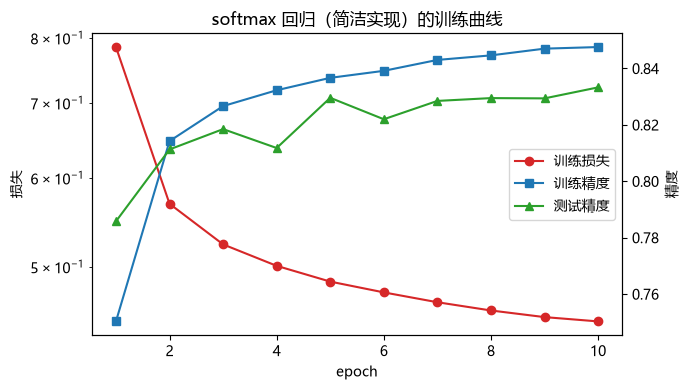

In [90]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)